<img src="https://d33wubrfki0l68.cloudfront.net/22691a3c3002324451ed99f4009de8aab761e1b7/d24da/public/images-original/stac-01.png"
     style="margin-right: 10px; width: 20%"/>

# Discover and Access Data via the EODC STAC API

Datasets hosted at EODC are cataloged by making use of the [STAC](https://stacspec.org/en) (SpatioTemporal Asset Catalog) specifications. The catalog service is available as STAC API via [https://stac.eodc.eu/api/v1](https://stac.eodc.eu/api/v1) to enable users to discover and search for datasets filtering by space, time and other attributes. 

This notebook was presented during the EODC Webinar 1 on 22 July 2025.

Further Resources:

* [EODC Portal](https://portal.services.eodc.eu/)
* [EODC Explorer](https://portal.services.eodc.eu/explore)

## Data Access

In [ ]:
# COPY AND PASTE CODE FOR DATA ACCESS HERE
# Use the EODC Explorer to get a ready-to-use code snippet for data access.

import pystac
import rioxarray

item_url = "https://stac.eodc.eu/api/v1/collections/SENTINEL1_GMR0/items/GMR0_20250324T051851_D095_E050N014T1_EU010M_W0M4R1_S1AIWGRDH"

# Load the individual item metadata and sign the assets
item = pystac.Item.from_file(item_url)

# Open one of the data assets (other asset keys to use: 'VV')
asset_href = item.assets["VH"].href
ds = rioxarray.open_rasterio(asset_href)
ds

<xarray.DataArray (band: 1, y: 10000, x: 10000)> Size: 200MB
[100000000 values with dtype=int16]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 80kB 5e+06 5e+06 5e+06 ... 5.1e+06 5.1e+06 5.1e+06
  * y            (y) float64 80kB 1.5e+06 1.5e+06 1.5e+06 ... 1.4e+06 1.4e+06
    spatial_ref  int64 8B 0
Attributes: (12/28)
    layer_description:                                       Radiometric terr...
    layer_name:                                              Gamma-0 VH
    layer_scale_factor:                                      10
    processing_applied_orbit_type:                           None
    processing_area_projection_applied_flag:                 True
    processing_border_noise_removal_flag:                    False
    ...                                                      ...
    source_start_time:                                       2025-03-24T05:18...
    source_stop_time:                                        2025-03-24T05:19...
    AREA_OR_POINT:                                           Area
    _FillValue:                                              -9999
    scale_factor:                                            0.1
    add_offset:                                              0.0

Warning 1: HTTP response code on https://data.eodc.eu/collections/SENTINEL1_GMR0/W0M4R1/EQUI7_EU010M/E050N014T1/GMR0_20250324T051851__VH_D095_E050N014T1_EU010M_W0M4R1_S1AIWGRDH_EODC.tif.msk: 403
Warning 1: HTTP response code on https://data.eodc.eu/collections/SENTINEL1_GMR0/W0M4R1/EQUI7_EU010M/E050N014T1/GMR0_20250324T051851__VH_D095_E050N014T1_EU010M_W0M4R1_S1AIWGRDH_EODC.tif.MSK: 403


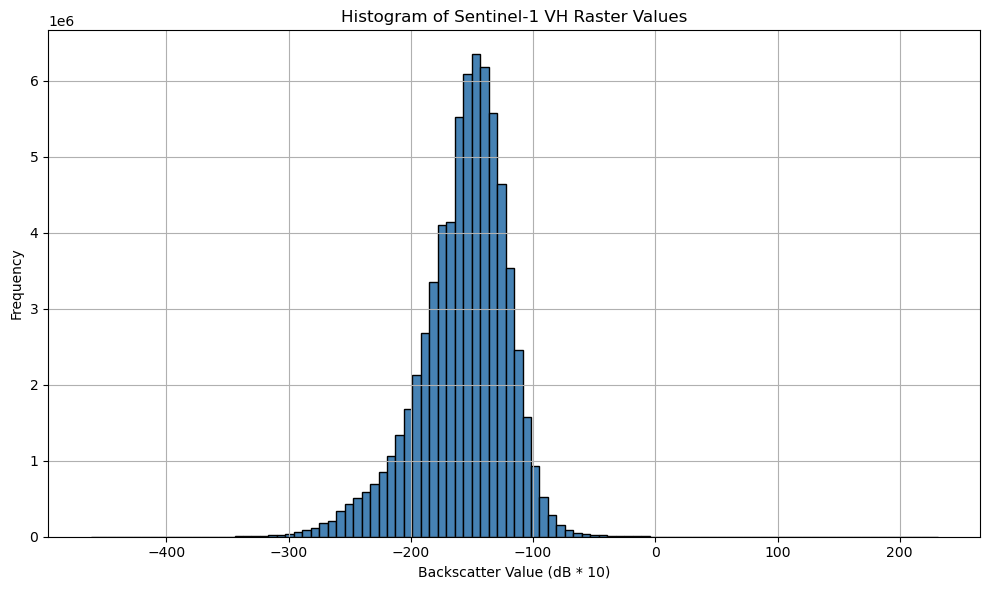

Suggested vmin: -250.00, vmax: -96.00


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Remove band dimension and mask nodata
data = ds.squeeze()
nodata = data.rio.nodata
masked_data = data.where(data != nodata)

# Flatten and drop NaNs
values = masked_data.values.flatten()
values = values[~np.isnan(values)]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(values, bins=100, color='steelblue', edgecolor='black')
plt.title("Histogram of Sentinel-1 VH Raster Values")
plt.xlabel("Backscatter Value (dB * 10)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute percentiles
vmin = np.percentile(values, 2)
vmax = np.percentile(values, 98)
print(f"Suggested vmin: {vmin:.2f}, vmax: {vmax:.2f}")



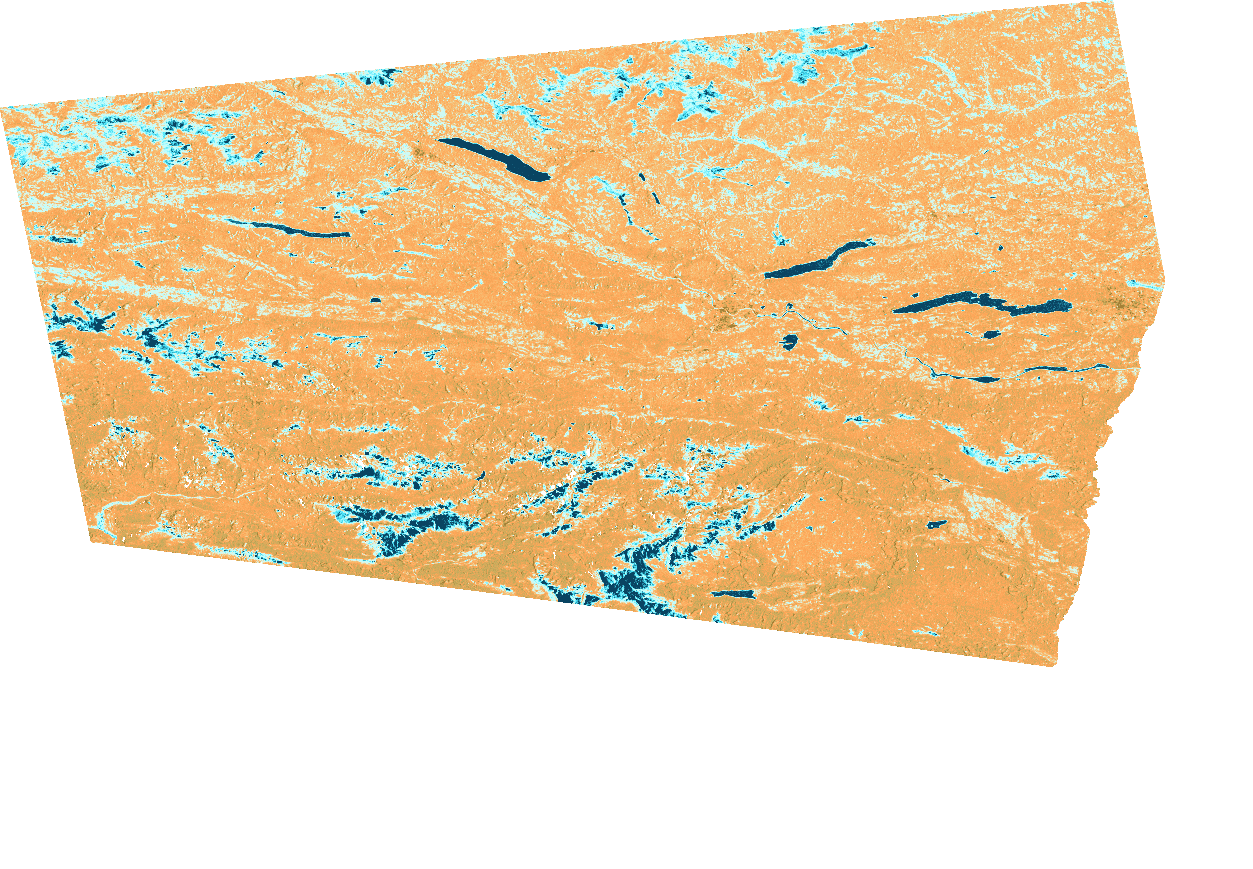

In [3]:
import folium
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Reproject to WGS84
ds_wgs84 = ds.rio.reproject("EPSG:4326")

# Remove band dimension and mask nodata
data = ds_wgs84.squeeze()
data = data.where(data != data.rio.nodata)

# Downsample to reduce memory usage
data_coarse = data.coarsen(x=10, y=10, boundary='trim').mean()

# Normalize using vmin and vmax
clipped = data_coarse.clip(min=vmin, max=vmax)
normalized = (clipped - vmin) / (vmax - vmin)
image_array = normalized.values

# Define custom colormap
eodc_colors = [
    "#083A59", "#3CBEE0", "#A0D7E7", "#B9D1D6",
    "#D1A36B", "#D88C50", "#A89255", "#8B6C32"
]
eodc_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", eodc_colors)

# Convert to RGBA
rgba_image = eodc_cmap(image_array)

# Get bounds
bounds = data_coarse.rio.bounds()
image_bounds = [[bounds[1], bounds[0]], [bounds[3], bounds[2]]]

# Create map
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2
f = folium.Figure(width='800px', height='600px')
m = folium.Map(location=[center_lat, center_lon], zoom_start=10).add_to(f)

# Add image overlay
folium.raster_layers.ImageOverlay(
    image=rgba_image,
    bounds=image_bounds,
    opacity=0.8,
    interactive=True,
    cross_origin=False,
    zindex=1,
).add_to(m)

folium.LayerControl().add_to(m)

m

## Data Discovery

In [ ]:
# COPY AND PASTE CODE FOR DATA DISCOVERY HERE
# Use the EODC Explorer to get a ready-to-use code snippet for data discovery.

from pystac_client import Client

# Search against the EODC STAC API
catalog = Client.open(
  "https://stac.eodc.eu/api/v1"
)

# Define your area of interest
aoi = {
  "type": "Polygon",
  "coordinates": [
    [
      [12.345886230468752, 45.908166581916824],
      [15.269622802734375, 45.908166581916824],
      [15.269622802734375, 46.98587362966408],
      [12.345886230468752, 46.98587362966408],
      [12.345886230468752, 45.908166581916824]
    ]
  ]
}

# Define your temporal range
daterange = {"interval": ["2025-01-01T00:00:00Z", "2025-07-22T23:59:59Z"]}

# Define your search with CQL2 syntax
search = catalog.search(filter_lang="cql2-json", filter={
  "op": "and",
  "args": [
    {"op": "s_intersects", "args": [{"property": "geometry"}, aoi]},
    {"op": "anyinteracts", "args": [{"property": "datetime"}, daterange]},
    {"op": "=", "args": [{"property": "collection"}, "SENTINEL1_GMR0"]}
  ]
})

# Grab the first item from the search results and sign the assets
first_item = next(search.items())
first_item.assets

{'VH': <Asset href=https://data.eodc.eu/collections/SENTINEL1_GMR0/W0M4R1/EQUI7_EU010M/E051N015T1/GMR0_20250327T165113__VH_A146_E051N015T1_EU010M_W0M4R1_S1AIWGRDH_EODC.tif>,
 'VV': <Asset href=https://data.eodc.eu/collections/SENTINEL1_GMR0/W0M4R1/EQUI7_EU010M/E051N015T1/GMR0_20250327T165113__VV_A146_E051N015T1_EU010M_W0M4R1_S1AIWGRDH_EODC.tif>,
 'metadata': <Asset href=https://data.eodc.eu/collections/SENTINEL1_GMR0/W0M4R1/EQUI7_EU010M/E051N015T1/GMR0_20250327T165113__DV_A146_E051N015T1_EU010M_W0M4R1_S1AIWGRDH_EODC.json>,
 'tilejson': <Asset href=https://titiler.services.eodc.eu/cog/WebMercatorQuad/tilejson.json?url=https%3A%2F%2Fdata.eodc.eu%2Fcollections%2FSENTINEL1_GMR0%2FW0M4R1%2FEQUI7_EU010M%2FE051N015T1%2FGMR0_20250327T165113__VV_A146_E051N015T1_EU010M_W0M4R1_S1AIWGRDH_EODC.tif&bidx=1&unscale=True&rescale=-20%2C-2&return_mask=True>,
 'thumbnail': <Asset href=https://data.eodc.eu/collections/SENTINEL1_GMR0/W0M4R1/EQUI7_EU010M/E051N015T1/GMR0_20250327T165113__VV_A146_E051N015T1_EU

In [5]:
items = search.items()
print(f"Found {len(list(items))} items matching the search criteria.")

Found 355 items matching the search criteria.


In [6]:
filter_orbit = {
  "op": "and",
  "args": [
    {"op": "s_intersects", "args": [{"property": "geometry"}, aoi]},
    {"op": "anyinteracts", "args": [{"property": "datetime"}, daterange]},
    {"op": "=", "args": [{"property": "collection"}, "SENTINEL1_GMR0"]},
    {"op": "=", "args": [{"property": "properties.sat:orbit_state"}, "descending"]}
  ]
}

search = catalog.search(filter_lang="cql2-json", filter=filter_orbit)

items = search.items()
print(f"Found {len(list(items))} items matching the search criteria.")

Found 158 items matching the search criteria.
